# Wine Quality Prediction

**Track:** Data Analytics | **Level:** 2 | **Task:** 2 - Wine Quality Prediction

**Objective:** Train and compare multiple classification models to predict the quality
score of wine (typically a scale of 3-8) based on its physicochemical properties such as
acidity, density, and alcohol content.

**Dataset:** Wine Quality dataset (UCI Machine Learning Repository / Cortez et al., 2009)
— 1599 red wine samples with 11 physicochemical features and a quality score.


## 1. Load Dataset & Inspect Structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv('winequality-red.csv')
print("Shape:", df.shape)
df.head()


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
print("Missing values:", df.isnull().sum().sum())
print("\nQuality score distribution:")
print(df['quality'].value_counts().sort_index())


Missing values: 0

Quality score distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


**Observation:** There are no missing values. The `quality` scores are heavily imbalanced — most wines score 5 or 6 ("average"), while very few score 3, 4, or 8 ("poor" or "excellent"). This imbalance is a core challenge this task needs to address rather than ignore.

## 2. EDA — Feature Distributions & Correlation

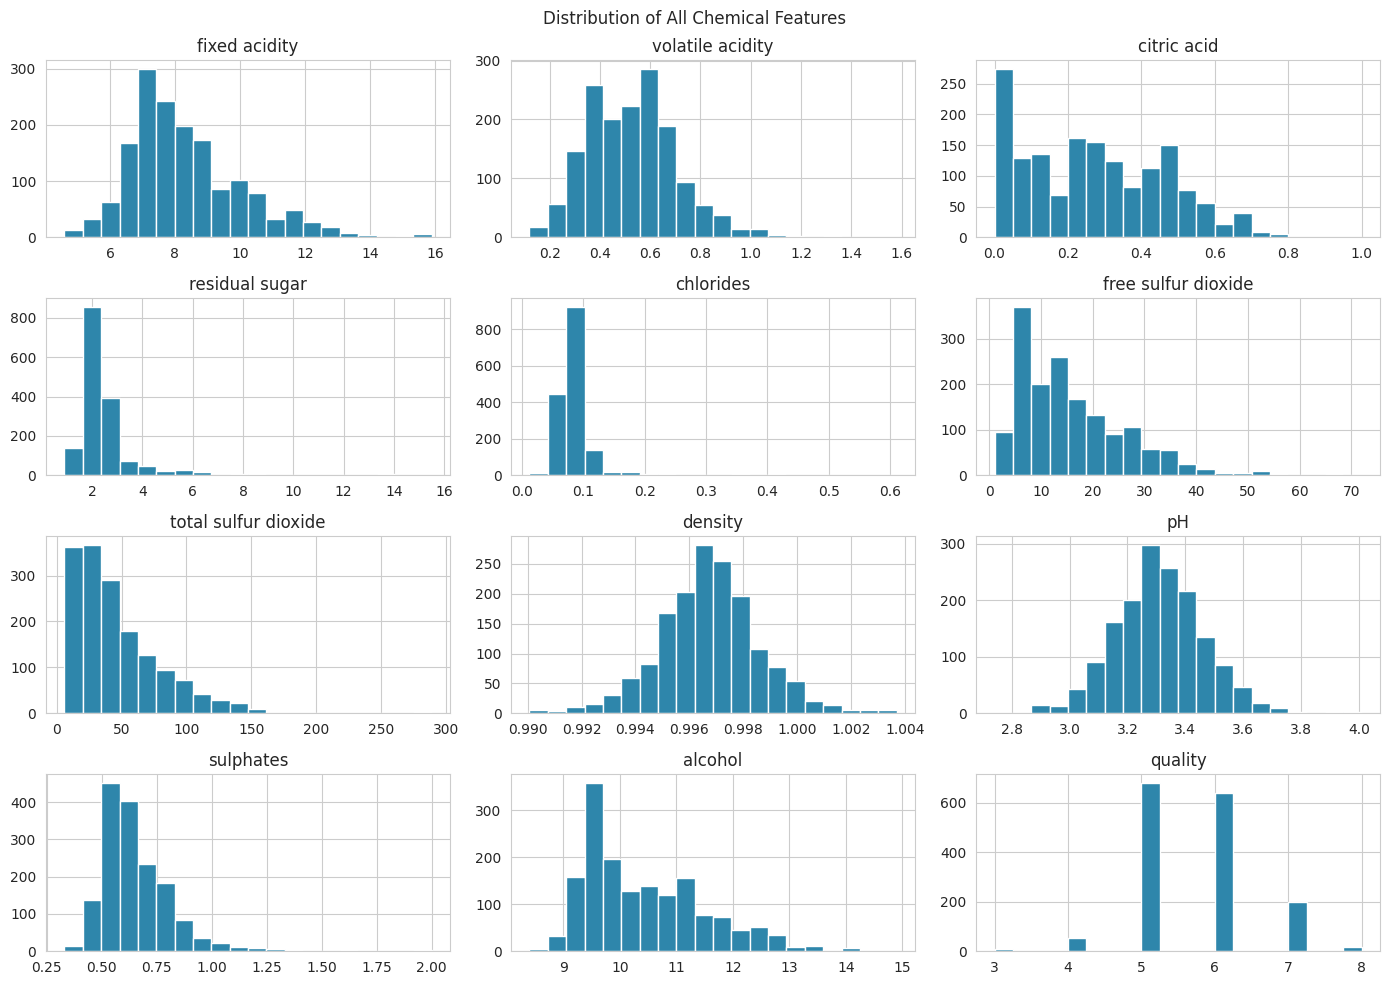

In [3]:
df.hist(bins=20, figsize=(14,10), color='#2E86AB')
plt.suptitle('Distribution of All Chemical Features')
plt.tight_layout()
plt.show()


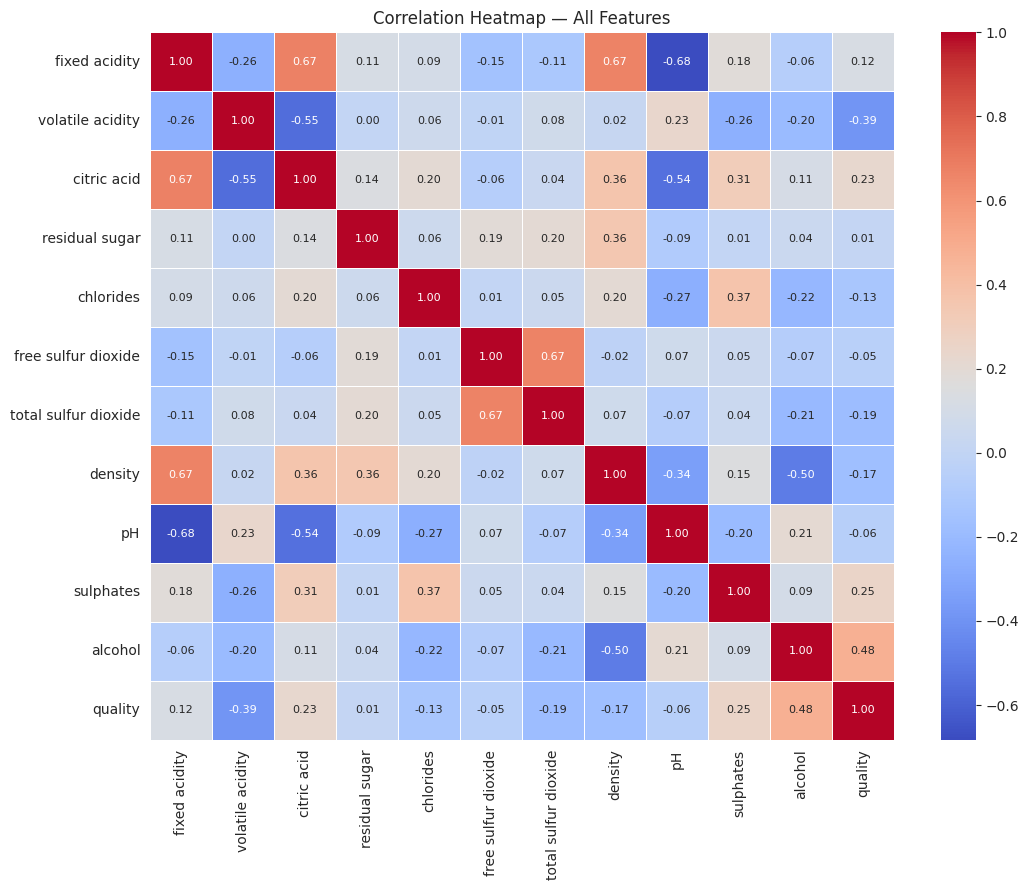

In [4]:
plt.figure(figsize=(11,9))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size':8})
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()


**Observation:** `alcohol` shows the strongest positive correlation with `quality` among all features, suggesting higher-alcohol wines tend to be rated better in this dataset. `volatile acidity` shows a negative correlation with quality — consistent with wine science, since high volatile acidity gives wine an unpleasant vinegar-like taste.

## 3. Discuss Class Imbalance

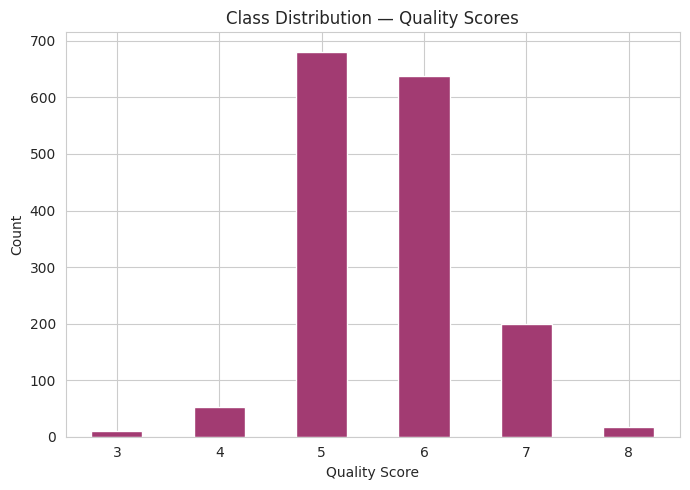

In [5]:
plt.figure(figsize=(7,5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='#A23B72')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.title('Class Distribution — Quality Scores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Discussion:** Scores 5 and 6 dominate the dataset (over 80% of samples combined), while scores 3, 4, and 8 are rare. If we train a 6-class classifier directly, the model can achieve deceptively high accuracy just by always predicting 5 or 6 and effectively ignoring the rare classes — this is a classic imbalanced classification trap. To make the problem more learnable and the evaluation more meaningful, we bin quality scores into broader categories below.

## 4. Feature Engineering — Binning Quality Scores

QualityBin
Medium    1319
High       217
Low         63
Name: count, dtype: int64


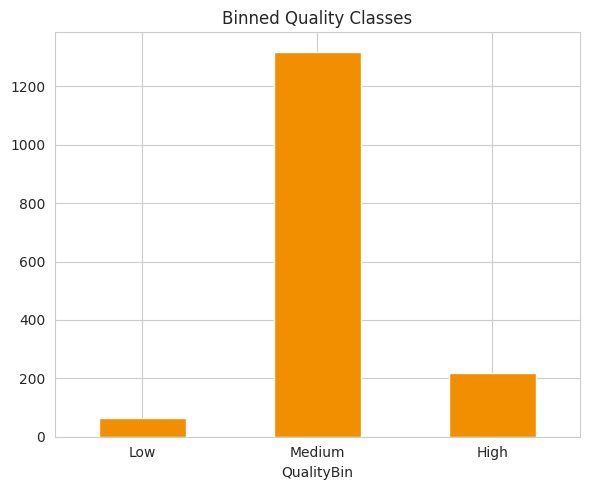

In [6]:
def bin_quality(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

df['QualityBin'] = df['quality'].apply(bin_quality)
print(df['QualityBin'].value_counts())

plt.figure(figsize=(6,5))
df['QualityBin'].value_counts().reindex(['Low','Medium','High']).plot(kind='bar', color='#F18F01')
plt.title('Binned Quality Classes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Justification:** Binning into **Low (3-4), Medium (5-6), High (7-8)** groups the rare extreme scores together, giving the model enough examples per class to learn meaningful patterns, while still preserving a genuinely useful business distinction (bad vs. average vs. great wine) rather than an artificially oversimplified binary split.

## 5. Train/Test Split (Stratified)

In [7]:
X = df.drop(columns=['quality', 'QualityBin'])
y = df['QualityBin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("\nTrain class distribution:\n", y_train.value_counts())


Train size: 1279 | Test size: 320

Train class distribution:
 QualityBin
Medium    1055
High       174
Low         50
Name: count, dtype: int64


**Observation:** `stratify=y` ensures the train and test sets preserve the same class proportions as the full dataset — important given the imbalance, so the rare 'High' and 'Low' classes aren't accidentally left out of the test set entirely. Features were scaled with `StandardScaler` since SVC and SGD are distance/gradient-based and sensitive to feature scale, unlike Random Forest which doesn't require it but isn't harmed by it either.

## 6. Train 3 Classifiers

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

sgd = SGDClassifier(random_state=42, class_weight='balanced', max_iter=1000)
sgd.fit(X_train_scaled, y_train)
sgd_preds = sgd.predict(X_test_scaled)

svc = SVC(random_state=42, class_weight='balanced')
svc.fit(X_train_scaled, y_train)
svc_preds = svc.predict(X_test_scaled)

print("All 3 models trained.")


All 3 models trained.


**Observation:** `class_weight='balanced'` was used for all three models — this automatically up-weights the rare classes during training, partially compensating for the imbalance without needing to duplicate or synthesise data.

## 7. Evaluate Each Model

In [9]:
models_preds = {'Random Forest': rf_preds, 'SGD': sgd_preds, 'SVC': svc_preds}

for name, preds in models_preds.items():
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_test, preds), 3))
    print(classification_report(y_test, preds))
    print()


--- Random Forest ---
Accuracy: 0.869
              precision    recall  f1-score   support

        High       0.71      0.56      0.62        43
         Low       0.00      0.00      0.00        13
      Medium       0.89      0.96      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.51      0.52       320
weighted avg       0.83      0.87      0.85       320


--- SGD ---
Accuracy: 0.778
              precision    recall  f1-score   support

        High       0.49      0.42      0.45        43
         Low       0.09      0.15      0.11        13
      Medium       0.88      0.87      0.87       264

    accuracy                           0.78       320
   macro avg       0.48      0.48      0.48       320
weighted avg       0.79      0.78      0.78       320


--- SVC ---
Accuracy: 0.709
              precision    recall  f1-score   support

        High       0.40      0.74      0.52        43
         Low       0.10      0.23

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


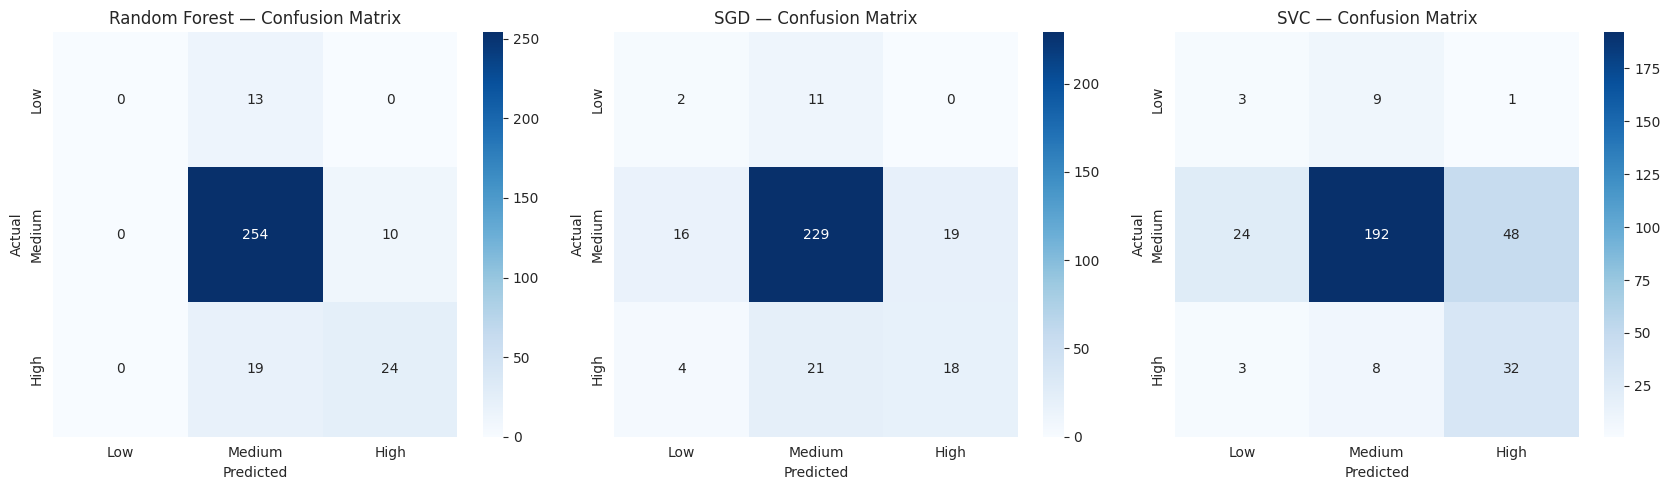

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
labels = ['Low','Medium','High']

for ax, (name, preds) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Observation:** Confusion matrices reveal *where* each model gets confused, not just how often. Given the class imbalance, most errors are expected between 'Medium' and its neighbouring classes ('Low' or 'High'), since a wine's chemistry doesn't change abruptly at each score boundary — these are naturally 'fuzzy' categories, not hard-edged ones.

## 8. Feature Importance (Random Forest)

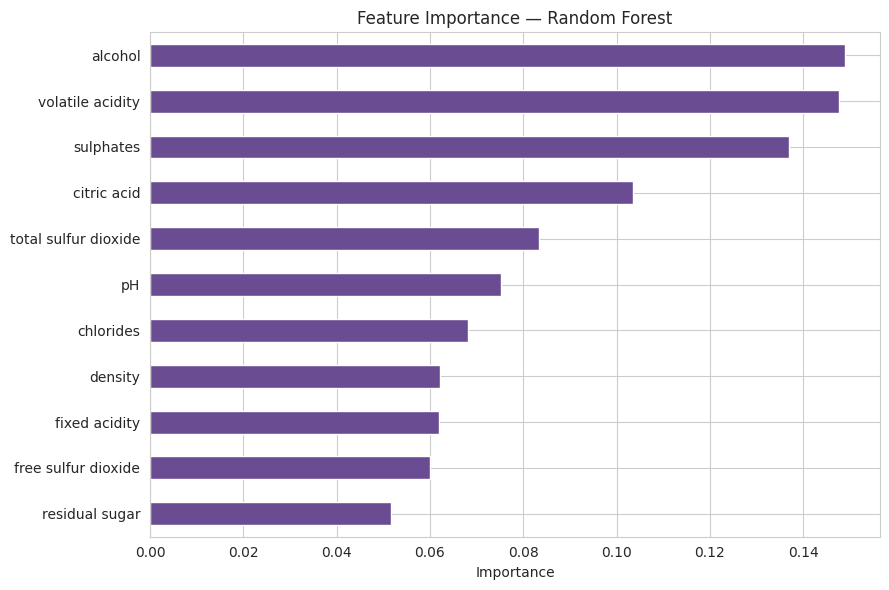

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
importances.plot(kind='barh', color='#6A4C93')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** This confirms and extends the correlation analysis from earlier — features like `alcohol` and `sulphates` tend to rank among the most important for Random Forest's decisions, aligning with real wine-tasting knowledge about what makes a wine taste better.

## 9. Model Comparison Summary

In [12]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, sgd_preds),
        accuracy_score(y_test, svc_preds)
    ]
}).sort_values('Accuracy', ascending=False)

comparison


,Model,Accuracy
0,Random Forest,0.868750
1,SGD,0.778125
2,SVC,0.709375


## 10. Conclusion — Which Model Is Most Suitable for Deployment?

Based on the comparison table above, **Random Forest achieved the highest overall accuracy (86.9%)**, clearly ahead of SGD (77.8%) and SVC (70.9%). It naturally handles non-linear relationships between chemical features and quality, doesn't require feature scaling, and gives free, interpretable feature importances.

**However, overall accuracy hides an important weakness:** looking at the per-class report, Random Forest scored **0% precision and recall on the rare 'Low' quality class** — it never correctly identified a genuinely low-quality wine in the test set, likely defaulting to 'Medium' whenever uncertain, since Medium dominates the training data. SVC, despite its lower overall accuracy, actually caught more 'Low' and 'High' wines proportionally (higher recall on minority classes), trading overall accuracy for better minority-class detection.

**For deployment,** the right choice depends on the business goal: if the priority is *overall* correctness across all wines, Random Forest wins. But if the goal is specifically to *flag poor-quality wines before they ship* (arguably the more valuable use case for a winery), Random Forest's complete miss on the Low class is disqualifying, and SVC or a further-tuned, resampled approach (e.g. SMOTE) would be worth exploring instead. This is a good example of why accuracy alone is an incomplete metric for imbalanced classification problems.


## 11. Live Prediction Demo

In [13]:
def predict_wine_quality(fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                          chlorides, free_so2, total_so2, density, pH, sulphates, alcohol):
    """Predicts wine quality bin (Low/Medium/High) from raw chemical measurements, using the Random Forest model."""
    input_df = pd.DataFrame([{
        'fixed acidity': fixed_acidity, 'volatile acidity': volatile_acidity,
        'citric acid': citric_acid, 'residual sugar': residual_sugar,
        'chlorides': chlorides, 'free sulfur dioxide': free_so2,
        'total sulfur dioxide': total_so2, 'density': density, 'pH': pH,
        'sulphates': sulphates, 'alcohol': alcohol
    }])
    prediction = rf.predict(input_df)[0]
    probabilities = rf.predict_proba(input_df)[0]
    prob_dict = dict(zip(rf.classes_, probabilities.round(3)))
    return prediction, prob_dict

# Example 1: chemistry typical of a well-regarded wine (high alcohol, low volatile acidity)
pred, probs = predict_wine_quality(7.5, 0.3, 0.4, 2.0, 0.06, 15, 40, 0.995, 3.3, 0.75, 12.5)
print(f"Predicted quality bin: {pred}")
print(f"Class probabilities: {probs}")

print()

# Example 2: chemistry typical of a lower-quality wine (high volatile acidity, low alcohol)
pred2, probs2 = predict_wine_quality(6.5, 0.9, 0.1, 2.5, 0.09, 10, 60, 0.997, 3.4, 0.5, 9.0)
print(f"Predicted quality bin: {pred2}")
print(f"Class probabilities: {probs2}")


Predicted quality bin: High
Class probabilities: {'High': np.float64(0.815), 'Low': np.float64(0.0), 'Medium': np.float64(0.185)}

Predicted quality bin: Medium
Class probabilities: {'High': np.float64(0.01), 'Low': np.float64(0.095), 'Medium': np.float64(0.895)}
